In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_validate

In [2]:
DATASET_DIR = Path(r"C:\Users\maria\PycharmProjects\DeepLerning\plantvillage dataset\color")

print(DATASET_DIR.exists())

True


In [3]:
class_pairs = [
    (
        "Apple___healthy",
        "Apple___Apple_scab"
    ),
    (
        "Potato___healthy",
        "Potato___Early_blight"
    ),
    (
        "Tomato___healthy",
        "Tomato___Early_blight"
    )
]

obraz RGB 64x64x3 → wektor długości 64 * 64 * 3

In [4]:
def load_binary_image_dataset(
    dataset_dir,
    class_0,
    class_1,
    image_size=(64, 64),
    max_images_per_class=None
):
    X = []
    y = []

    classes = [
        (class_0, 0),
        (class_1, 1)
    ]

    for class_name, label in classes:
        class_dir = dataset_dir / class_name

        if not class_dir.exists():
            raise FileNotFoundError(f"Nie znaleziono folderu: {class_dir}")

        image_paths = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))

        if max_images_per_class is not None:
            image_paths = image_paths[:max_images_per_class]

        print(f"{class_name}: {len(image_paths)} obrazów")

        for image_path in image_paths:
            try:
                image = Image.open(image_path).convert("RGB")
                image = image.resize(image_size)

                image_array = np.array(image)

                # Spłaszczenie obrazu do jednego wektora
                image_vector = image_array.reshape(-1)

                X.append(image_vector)
                y.append(label)

            except Exception as e:
                print(f"Problem z plikiem {image_path}: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    # Normalizacja pikseli z zakresu 0-255 do 0-1
    X = X / 255.0

    return X, y

W każdym przypadku podziel zbiór obrazów danej pary klas na zbiór treningowy i testowy (tutaj podzieliłem 80/20).

In [5]:
def evaluate_train_test(
    dataset_dir,
    class_0,
    class_1,
    image_size=(64, 64),
    max_images_per_class=500,
    test_size=0.2,
    random_state=42
):
    X, y = load_binary_image_dataset(
        dataset_dir=dataset_dir,
        class_0=class_0,
        class_1=class_1,
        image_size=image_size,
        max_images_per_class=max_images_per_class
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return {
        "class_0": class_0,
        "class_1": class_1,
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

Wariant z walidacją krzyżową

In [6]:
def evaluate_cross_validation(
    dataset_dir,
    class_0,
    class_1,
    image_size=(64, 64),
    max_images_per_class=500,
    cv_splits=5,
    random_state=42
):
    X, y = load_binary_image_dataset(
        dataset_dir=dataset_dir,
        class_0=class_0,
        class_1=class_1,
        image_size=image_size,
        max_images_per_class=max_images_per_class
    )

    model = LogisticRegression(max_iter=1000)

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "recall", "precision", "f1"]
    )

    return {
        "class_0": class_0,
        "class_1": class_1,
        "accuracy": scores["test_accuracy"].mean(),
        "recall": scores["test_recall"].mean(),
        "precision": scores["test_precision"].mean(),
        "f1": scores["test_f1"].mean()
    }

EKSPERYMENT

In [7]:
train_test_results = []
cross_validation_results = []

for class_0, class_1 in class_pairs:
    train_test_results.append(
        evaluate_train_test(
            dataset_dir=DATASET_DIR,
            class_0=class_0,
            class_1=class_1,
            image_size=(64, 64),
            max_images_per_class=500
        )
    )

    cross_validation_results.append(
        evaluate_cross_validation(
            dataset_dir=DATASET_DIR,
            class_0=class_0,
            class_1=class_1,
            image_size=(64, 64),
            max_images_per_class=500,
            cv_splits=5
        )
    )

Apple___healthy: 500 obrazów
Apple___Apple_scab: 500 obrazów
Apple___healthy: 500 obrazów
Apple___Apple_scab: 500 obrazów
Potato___healthy: 304 obrazów
Potato___Early_blight: 500 obrazów
Potato___healthy: 304 obrazów
Potato___Early_blight: 500 obrazów
Tomato___healthy: 500 obrazów
Tomato___Early_blight: 500 obrazów
Tomato___healthy: 500 obrazów
Tomato___Early_blight: 500 obrazów


Zestawienie wyników

In [10]:
summary = pd.DataFrame([
    {
        "Para klas": f"{tt['class_0']} vs {tt['class_1']}",

        "Train/Test Accuracy": tt["accuracy"],
        "CV Accuracy": cv["accuracy"],

        "Train/Test Recall": tt["recall"],
        "CV Recall": cv["recall"],

        "Train/Test Precision": tt["precision"],
        "CV Precision": cv["precision"],

        "Train/Test F1": tt["f1"],
        "CV F1": cv["f1"]
    }
    for tt, cv in zip(train_test_results, cross_validation_results)
])

summary

,Para klas,Train/Test Accuracy,CV Accuracy,Train/Test Recall,CV Recall,Train/Test Precision,CV Precision,Train/Test F1,CV F1
0,Apple___healthy vs Apple___Apple_scab,0.925,0.92500,0.94,0.922,0.912621,0.928386,0.926108,0.924978
1,Potato___healthy vs Potato___Early_blight,1.000,0.98882,1.00,0.982,1.000000,1.000000,1.000000,0.990736
2,Tomato___healthy vs Tomato___Early_blight,0.950,0.93900,0.94,0.938,0.959184,0.939913,0.949495,0.938577


wyniki jako wykres

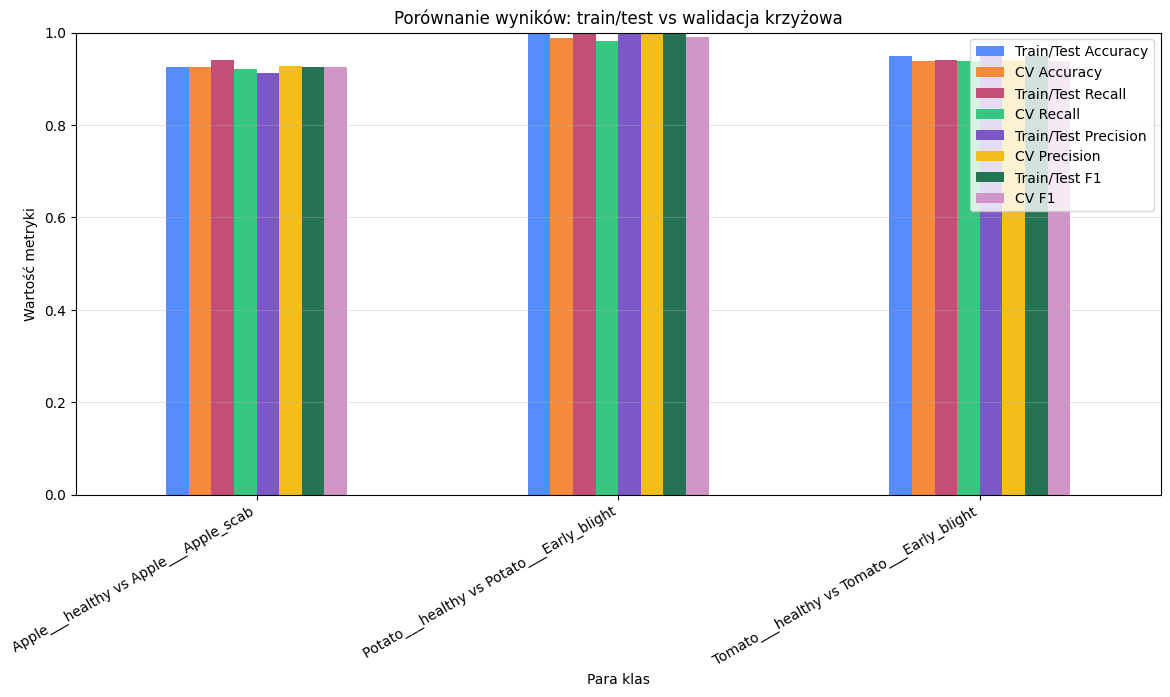

In [11]:
summary_plot = summary.set_index("Para klas")

summary_plot.plot(
    kind="bar",
    figsize=(14, 6),
    ylim=(0, 1),
    title="Porównanie wyników: train/test vs walidacja krzyżowa"
)

plt.ylabel("Wartość metryki")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()